# Tensile Disk Analysis
Concise, reproducible version with shared utilities upfront.

In [1]:
# Auto-reload external modules after saving them
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# normal imports
from tools.bound_all_helpers import *

In [2]:
# The displacement-discontinuity toolkit below was defined inline in both
# notebooks. It now lives in tools/ddm/ so the two lithologies provably
# share one implementation. Names are unchanged, so every call site below
# reads exactly as before.
from tools.ddm import (  # noqa: F401
    # angles — Angle wrapping, axial statistics and orientation blending.
    angle_axis, axial_stats_from_delta, axis_angle, deviation_arrays,
    trough_angle_from_xi, wrap_axis_angle,
    # elasticity — Orthotropic constitutive relations, stresses and strains.
    band_open_factor_from_sigma_n, compute_sample_stresses, modulus_to_Pa_from_csv,
    nominal_splitting_stress, orthotropic_roots_p, principal_from_components,
    principal_strain_and_angle, principal_stresses_and_angle,
    q_matrix_plane_stress_orthotropic, required_load_for_target_sigma_t,
    sigma1_plus, splitting_stress_pa,
    strain_energy_density_ortho_plane_stress_material,
    strains_from_stress_TIsotropic, surrogate_tensile_weight,
    tensile_stress_from_sigma1_theta, transform_Q_to_angle,
    # failure — Failure criteria, weak-band weighting and contact/platen models.
    _safe_compute_psi_pref, _safe_wp_weight, build_psi_pref_field,
    compute_wp_weight_img, disk_failure_stats_all_points, evaluate_failure_mode,
    evaluate_failure_mode_mohr_coulomb_constant, get_anisotropy_ratio,
    hertz_contact_halfwidth, platen_weight, surrogate_conf_weight,
    surrogate_energy_proxy, surrogate_wp_weight,
    # figures — Publication figure helpers.
    _get_marker, _label_full, _label_short, _make_all_combined_plots,
    _mode_to_code_img, apply_plot_style, make_figure1, make_figure2,
    plot_direction_circle, set_pub_style,
    # fitting — Model fitting, metrics and measured-data comparison.
    choose_smallest_near_peak, compare_with_measured_data, fit_coeffs_collocation,
    generate_random_props, get_row_material_props, pooled_equal_weight_abs_delta,
    print_material_parameters, summarize_distribution, summarize_modes,
    # grids — Disc grids, masks, polylines and segment geometry.
    _grid_axes, _grid_axes_from_mesh, _grid_cell_area, _img_from_mask,
    _polyline_length, _thin_points_for_glyphs, build_segments_from_axis,
    clip_to_disk, create_grid_mesh, create_structured_grid,
    create_triangular_mesh_in_disk, downsample_mask, make_segments,
    reconstruct_grid, reconstruct_grid_and_mask, sample_line,
    snap_path_to_platen_arcs, valid_mask_from_fields,
    # io — Field archive read/write, path discovery and solver binding.
    _search_dirs, bind_sif_hooks, get_first_col, import_or_load_solver,
    load_module_from_path, load_sample_fields_physical, npz_path_for_sample,
    output_prefix_from_records, replot_from_csvs, sanitize_name,
    save_all_energy_plot, save_all_paths_plot, save_all_ratio_plot,
    save_full_fields_npz, save_sample_fields_npz, validate_solver_api,
    # smoothing — Smoothing, kernel density, bootstrap bands and curve collapse.
    compute_poly_ci, gaussian_kde_manual, gaussian_smooth_1d, mean_profile_midband,
    nan_box_blur, nearest_mean, robust_bandwidth,
    # solver — Finite-difference operators, tractions and the energy-guided stepper.
    _adaptive_N_outer, _adaptive_kink_n, _normalize_rock_name,
    bilinear_sample_scalar, bilinear_scalar, check_force_equilibrium,
    integrate_line_force, traction_from_coeffs_on_boundary,
)

print(f'tools.ddm: {len(__import__("tools.ddm", fromlist=["x"]).__all__)} shared names imported')


tools.ddm: 119 shared names imported


In [3]:
import os
import copy
import sys
import warnings
import argparse
import inspect
import json
import time
import math
import scipy
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.colors as mcolors


from pathlib import Path
from scipy.optimize import curve_fit
from collections import deque
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch
from matplotlib.colors import TwoSlopeNorm
from scipy.integrate import simpson
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from scipy.stats import norm, t
from scipy import stats

sns.set_theme(style="ticks")

DATA_PATH = Path("tensile_samples_data.csv")
OUTPUT_DIR = Path.cwd() / "Output_Figures"
OUTPUT_DIR.mkdir(exist_ok=True)

PLOT_STYLE = {
    'font.family': 'Times New Roman',
    'font.size': 14,
    'axes.linewidth': 1.5,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'text.usetex': False,
}


# =======================================================
# Plot style
# =======================================================
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 14,
    'axes.linewidth': 1.5,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'text.usetex': False,
})

tick_params = {
    'major': {'which': 'major', 'direction': 'out', 'length': 5, 'width': 1.5},
    'minor': {'which': 'minor', 'direction': 'out', 'length': 3, 'width': 1}
}


TICK_PARAMS = {
    'major': {'which': 'major', 'direction': 'out', 'length': 5, 'width': 1.5},
    'minor': {'which': 'minor', 'direction': 'out', 'length': 3, 'width': 1},
}


def load_samples(path: Path = DATA_PATH) -> pd.DataFrame:
    return pd.read_csv(path, delimiter=",", header=0, index_col=0)

def wrap_pi(angle):
    return ((angle + np.pi) % (2 * np.pi)) - np.pi

def angle_diff_periodic(a, b):
    return wrap_pi(a - b)


def anisotropic_tensile_strength(base_tensile_strength_mpa, anisotropic_angle, orientation, spacing, radius):
    dphi = angle_diff_periodic(anisotropic_angle, orientation)
    reduction = np.cos(dphi) ** 2
    distance_to_plane = np.abs(radius * np.sin(dphi)) % spacing
    spacing_effect = np.cos(np.pi * distance_to_plane / spacing) ** 2
    return base_tensile_strength_mpa * reduction * spacing_effect

def create_triangular_mesh(diameter, num_points=40000, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    radius = diameter / 2.0
    angles = rng.uniform(0.0, 2.0 * np.pi, num_points)
    radii = np.sqrt(rng.uniform(0.0, 1.0, num_points)) * radius
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)
    triangulation = tri.Triangulation(x, y)
    radial_distance = np.sqrt(x ** 2 + y ** 2)
    return triangulation, radial_distance, x, y


def evaluate_failure_mode_mohr_coulomb_local(sigma_1, sigma_3,
                                             tensile_strength_arr,
                                             cohesion_arr, friction_angle_arr,
                                             k_max=0.70, cohesion_floor=0.05,
                                             report_counts=False):
    sigma_1 = np.asarray(sigma_1)
    sigma_3 = np.asarray(sigma_3)
    tensile_strength_arr = np.asarray(tensile_strength_arr)
    cohesion_arr = np.asarray(cohesion_arr)
    friction_angle_arr = np.asarray(friction_angle_arr)

    sigma_m = 0.5 * (sigma_1 + sigma_3)
    tau_max = 0.5 * (sigma_1 - sigma_3)

    sigma_ref = float(np.mean(tensile_strength_arr))
    k_field = k_max * (1.0 - np.exp(-np.abs(sigma_m) / (sigma_ref + 1e-9)))
    effective_cohesion = np.maximum(cohesion_arr * (1.0 - k_field), cohesion_floor)

    sigma_m_comp = np.maximum(0.0, -sigma_m)
    tension_crit = sigma_1 >= tensile_strength_arr
    shear_strength = effective_cohesion + sigma_m_comp * np.tan(friction_angle_arr)
    shear_crit = tau_max >= shear_strength

    mode = np.full(sigma_1.shape, 'no_failure', dtype=object)
    mode[tension_crit & shear_crit] = 'mixed'
    mode[tension_crit & ~shear_crit] = 'tensile'
    mode[shear_crit & ~tension_crit] = 'shear'

    if report_counts:
        print(f"  Tensile pts: {np.sum(tension_crit)}")
        print(f"  Shear pts:   {np.sum(shear_crit)}")
        print(f"  Mixed pts:   {np.sum(tension_crit & shear_crit)}")
        print(f"  No-failure pts: {np.sum(mode == 'no_failure')}")

    return mode


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import differential_evolution, least_squares
from sklearn.utils import resample
from tools.data_io import load_replicate_table

# ── Output ──────────────────────────────────────────────────────────────────
output_dir = os.path.join(os.getcwd(), "Output_Figures")
os.makedirs(output_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,
    "axes.linewidth": 1.4,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

EPS = 1e-12

# ------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------
CSV_PATH = "selected_all_samples.csv"
df = load_replicate_table()

df = df.copy()
df["Angle"] = pd.to_numeric(df["Angle"], errors="coerce")
df["Tensile_strength_Mpa"] = pd.to_numeric(df["Tensile_strength_Mpa"], errors="coerce")
df = df.dropna(subset=["Angle", "Tensile_strength_Mpa", "Rock_type"])
df = df[(df["Angle"] >= 0) & (df["Angle"] <= 90)].copy()

augen_gneiss_data = df[df["Rock_type"] == "Augen gneiss"].copy()
psammatic_schist_data = df[df["Rock_type"] == "Psammitic schist"].copy()

print("Augen rows:", len(augen_gneiss_data))
print("Psammatic rows:", len(psammatic_schist_data))


# ------------------------------------------------------------
# 2) M7 model
# ------------------------------------------------------------
def model_TI_matrix(beta_rad, sigma0, sigma90):
    """
    TI matrix interpolation:
      sigma_TI(beta) = [cos²(beta)/sigma0² + sin²(beta)/sigma90²]^(-1/2)
    """
    beta_rad = np.asarray(beta_rad, dtype=float)
    c = np.cos(beta_rad)
    s = np.sin(beta_rad)
    return 1.0 / np.sqrt(c**2 / float(sigma0)**2 + s**2 / float(sigma90)**2)


def asym_activation(beta_rad, xi):
    """
    Normalized asymmetric activation function:
      g(beta, xi) = sin(beta)^(1+xi) * cos(beta)^(1-xi) / gmax(xi)
    """
    beta_rad = np.asarray(beta_rad, dtype=float)
    s = np.sin(beta_rad)
    c = np.cos(beta_rad)

    # sin and cos vanish exactly at the fabric end members, but in floating
    # point cos(pi/2) is ~6e-17 rather than 0. Raising a near-zero base to the
    # near-zero power q = 1 - xi (which tends to 0 as xi tends to 1) returns
    # ~0.5 instead of 0, so the activation would not switch off at 90 deg and
    # the curve would miss its own fitted sigma_90. Snap to zero so g vanishes
    # at both end members as the model requires.
    s = np.where(np.abs(s) < 1e-12, 0.0, s)
    c = np.where(np.abs(c) < 1e-12, 0.0, c)

    p = 1.0 + float(xi)
    q = 1.0 - float(xi)

    g_raw = (s**p) * (c**q)

    gmax = (p / 2.0)**(p / 2.0) * (q / 2.0)**(q / 2.0)
    gmax = max(gmax, EPS)

    return g_raw / gmax


def xi_from_u(u):
    """
    Internal unconstrained parameter u -> physical xi in (-0.85, 0.85).

    The bound keeps both activation exponents p = 1 + xi and q = 1 - xi at or
    above 0.15. At |xi| -> 1 one exponent tends to zero, the corresponding
    sin or cos factor stays near unity across the whole range and collapses
    only in an infinitesimal neighbourhood of an end member, and the
    activation degenerates into a step. Restricting |xi| <= 0.85 still admits
    trough angles up to 74 deg, which spans the measured minima.
    """
    return 0.85 * np.tanh(float(u))


def model_M7_asym_FPZ(beta_rad, sigma0, sigma90, eta, u):
    """
    M7 model:
      sigma(beta) = sigma_TI(beta) / sqrt(1 + eta * g(beta,xi)^2)
    """
    sigma_ti = model_TI_matrix(beta_rad, sigma0, sigma90)
    xi = xi_from_u(u)
    g = asym_activation(beta_rad, xi)
    return sigma_ti / np.sqrt(1.0 + float(eta) * g**2)


def model_func(angle_rad, sigma0, sigma90, eta, u):
    return model_M7_asym_FPZ(angle_rad, sigma0, sigma90, eta, u)


# ------------------------------------------------------------
# 3) Utilities
# ------------------------------------------------------------
def get_sigma_weights(df_rock):
    """
    Use per-angle sample std as fitting sigma.
    Falls back to global std when std at an angle is missing or zero.
    """
    ang_deg = df_rock["Angle"].to_numpy(float)
    y = df_rock["Tensile_strength_Mpa"].to_numpy(float)

    stats = (
        df_rock.groupby("Angle")["Tensile_strength_Mpa"]
        .agg(["std", "count"])
        .sort_index()
    )

    global_std = float(np.nanstd(y, ddof=1)) if len(y) > 1 else 1.0
    if not np.isfinite(global_std) or global_std <= 0:
        global_std = 1.0

    std_map = stats["std"].to_dict()
    sigma = np.array([std_map.get(a, np.nan) for a in ang_deg], dtype=float)
    sigma[~np.isfinite(sigma) | (sigma <= 0)] = global_std

    return np.clip(sigma, 1e-6, None)


def compute_metrics(y, yhat, sigma, k_params):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    resid = y - yhat

    n = len(y)
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))

    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean(resid ** 2)))

    ok = np.isfinite(sigma) & (sigma > 0)
    chi2 = float(np.sum((resid[ok] / sigma[ok]) ** 2))
    dof = max(1, int(np.sum(ok)) - k_params)
    red_chi2 = chi2 / dof

    return {
        "R2": r2,
        "RMSE": rmse,
        "red_chi2": red_chi2,
    }


def fit_model(func, df_rock, p0, bounds, k_params, use_de=True, robust=True):
    """
    Two-stage fit:
      1) differential evolution for global search
      2) least_squares refinement
    """
    ang_rad = np.deg2rad(df_rock["Angle"].to_numpy(float))
    y = df_rock["Tensile_strength_Mpa"].to_numpy(float)
    sigma = get_sigma_weights(df_rock)

    lo = np.asarray(bounds[0], float)
    hi = np.asarray(bounds[1], float)

    def residuals(p):
        return (func(ang_rad, *p) - y) / sigma

    if use_de:
        de_bounds = [(float(a), float(b)) for a, b in zip(lo, hi)]
        objective = lambda p: np.sum(residuals(p) ** 2)

        de_res = differential_evolution(
            objective,
            de_bounds,
            seed=42,
            maxiter=1500,
            popsize=18,
            tol=1e-8,
            polish=False,
            updating="deferred",
            workers=1,
        )
        x0 = de_res.x
    else:
        x0 = np.asarray(p0, float)

    ls = least_squares(
        residuals,
        x0=x0,
        bounds=(lo, hi),
        loss="soft_l1" if robust else "linear",
        f_scale=1.0,
        max_nfev=50000,
        x_scale="jac",
    )

    popt = ls.x
    yhat = func(ang_rad, *popt)
    metrics = compute_metrics(y, yhat, sigma, k_params)

    dof = max(1, len(y) - len(popt))
    try:
        J = ls.jac
        JTJ = J.T @ J
        s_sq = 2.0 * ls.cost / dof
        pcov = np.linalg.pinv(JTJ) * s_sq
        perr = np.sqrt(np.clip(np.diag(pcov), 0, None))
    except Exception:
        perr = np.full(len(popt), np.nan)

    return popt, perr, metrics


def curve_on_grid(popt, n_grid=361):
    ang_deg_grid = np.linspace(0, 90, n_grid)
    ang_rad_grid = np.deg2rad(ang_deg_grid)
    y_grid = model_func(ang_rad_grid, *popt)
    return ang_deg_grid, y_grid


def m7_report_params(popt, perr):
    sigma0, sigma90, eta, u = popt
    sigma0_err, sigma90_err, eta_err, u_err = perr

    xi = xi_from_u(u)
    dxi_du = 0.98 * (1.0 - np.tanh(u)**2)
    xi_err = abs(dxi_du) * u_err if np.isfinite(u_err) else np.nan

    return {
        "sigma0": sigma0,
        "sigma90": sigma90,
        "eta": eta,
        "xi": xi,
        "sigma0_err": sigma0_err,
        "sigma90_err": sigma90_err,
        "eta_err": eta_err,
        "xi_err": xi_err,
    }


def bootstrap_fit(df_rock, popt, n_boot=2000):
    """
    Bootstrap parameter fits for M7.

    Returns:
        ci: shape (2, 4), [2.5%, 97.5%]
        boot_params: successful bootstrap parameter vectors
    """
    df_fit = df_rock.copy()
    df_fit = df_fit.dropna(subset=["Angle", "Tensile_strength_Mpa"]).copy()

    boot_params = []
    bounds = ([0.2, 0.2, 0.0, -4.0], [30.0, 30.0, 10.0, 4.0])

    for _ in range(n_boot):
        idx = resample(np.arange(len(df_fit)), replace=True)
        boot_df = df_fit.iloc[idx].copy()

        try:
            p, _, _ = fit_model(
                model_func,
                boot_df,
                p0=popt,
                bounds=bounds,
                k_params=4,
                use_de=False,
                robust=True
            )
            boot_params.append(p)
        except Exception:
            pass

    boot_params = np.array(boot_params)

    if len(boot_params) == 0:
        return None, None

    ci = np.percentile(boot_params, [2.5, 97.5], axis=0)
    return ci, boot_params


def bootstrap_band(boot_params, ang_deg_grid):
    if boot_params is None or len(boot_params) == 0:
        return None, None

    ang_rad_grid = np.deg2rad(ang_deg_grid)
    curves = np.array([model_func(ang_rad_grid, *p) for p in boot_params])

    lower = np.percentile(curves, 2.5, axis=0)
    upper = np.percentile(curves, 97.5, axis=0)
    return lower, upper


def strength_anisotropy(df_rock, popt, rock_name):
    """
    Prints actual and model strength anisotropy.

    Definitions:
      anisotropy ratio = sigma_max / sigma_min
      anisotropy (%)   = (sigma_max - sigma_min) / sigma_max * 100
    """
    # ----------------------------
    # Actual anisotropy from angle means
    # ----------------------------
    stats = (
        df_rock.groupby("Angle")["Tensile_strength_Mpa"]
        .agg(["mean", "std", "count"])
        .sort_index()
    )

    obs_max = float(stats["mean"].max())
    obs_min = float(stats["mean"].min())
    obs_ratio = obs_max / obs_min if obs_min > 0 else np.nan
    obs_percent = ((obs_max - obs_min) / obs_max * 100.0) if obs_max > 0 else np.nan

    obs_max_angle = float(stats["mean"].idxmax())
    obs_min_angle = float(stats["mean"].idxmin())

    # ----------------------------
    # Model anisotropy from fitted curve
    # ----------------------------
    ang_deg_grid = np.linspace(0, 90, 2001)
    ang_rad_grid = np.deg2rad(ang_deg_grid)
    y_model = model_func(ang_rad_grid, *popt)

    mod_max = float(np.max(y_model))
    mod_min = float(np.min(y_model))
    mod_ratio = mod_max / mod_min if mod_min > 0 else np.nan
    mod_percent = ((mod_max - mod_min) / mod_max * 100.0) if mod_max > 0 else np.nan

    mod_max_angle = float(ang_deg_grid[np.argmax(y_model)])
    mod_min_angle = float(ang_deg_grid[np.argmin(y_model)])

    print(f"\n--- {rock_name} Strength Anisotropy ---")
    print("Actual data (from angle means):")
    print(f"  max mean strength = {obs_max:.4f} MPa at {obs_max_angle:.1f}°")
    print(f"  min mean strength = {obs_min:.4f} MPa at {obs_min_angle:.1f}°")
    print(f"  anisotropy ratio  = {obs_ratio:.4f}")
    print(f"  anisotropy (%)    = {obs_percent:.2f}%")

    print("Model fit:")
    print(f"  max modeled strength = {mod_max:.4f} MPa at {mod_max_angle:.2f}°")
    print(f"  min modeled strength = {mod_min:.4f} MPa at {mod_min_angle:.2f}°")
    print(f"  anisotropy ratio     = {mod_ratio:.4f}")
    print(f"  anisotropy (%)       = {mod_percent:.2f}%")

    return {
        "obs_max": obs_max,
        "obs_min": obs_min,
        "obs_ratio": obs_ratio,
        "obs_percent": obs_percent,
        "obs_max_angle": obs_max_angle,
        "obs_min_angle": obs_min_angle,
        "mod_max": mod_max,
        "mod_min": mod_min,
        "mod_ratio": mod_ratio,
        "mod_percent": mod_percent,
        "mod_max_angle": mod_max_angle,
        "mod_min_angle": mod_min_angle,
    }


# ------------------------------------------------------------
# 4) Fit per rock type
# ------------------------------------------------------------
def fit_one_rock(df_rock, rock_name):
    df_fit = df_rock.dropna(subset=["Angle", "Tensile_strength_Mpa"]).copy()

    ang_deg = df_fit["Angle"].to_numpy(float)
    y = df_fit["Tensile_strength_Mpa"].to_numpy(float)

    stats = (
        df_fit.groupby("Angle")["Tensile_strength_Mpa"]
        .agg(["mean", "std", "count", "sem"])
        .sort_index()
    )

    sigma0_guess = nearest_mean(stats, 0.0, float(np.nanmax(y)))
    sigma90_guess = nearest_mean(stats, 90.0, float(np.nanmin(y)))

    p0 = [max(0.2, sigma0_guess), max(0.2, sigma90_guess), 0.3, 0.0]
    bounds = ([0.2, 0.2, 0.0, -4.0], [30.0, 30.0, 10.0, 4.0])

    popt, perr, metrics = fit_model(
        model_func,
        df_fit,
        p0=p0,
        bounds=bounds,
        k_params=4,
        use_de=True,
        robust=True
    )

    rep = m7_report_params(popt, perr)
    beta_star = trough_angle_from_xi(rep["xi"])

    print(f"\n--- {rock_name} Equation FIT ---")
    print(f"sigma0  = {rep['sigma0']:.4f} ± {rep['sigma0_err']:.4f} MPa")
    print(f"sigma90 = {rep['sigma90']:.4f} ± {rep['sigma90_err']:.4f} MPa")
    print(f"eta     = {rep['eta']:.4f} ± {rep['eta_err']:.4f}")
    print(f"xi      = {rep['xi']:.4f} ± {rep['xi_err']:.4f}")
    print(f"trough center ≈ {beta_star:.2f}°")
    print(
        f"R² = {metrics['R2']:.4f}   "
        f"RMSE = {metrics['RMSE']:.4f} MPa   "
        f"χ²red = {metrics['red_chi2']:.3f}"
    )

    return popt, perr, metrics


# Fit and store
if len(augen_gneiss_data) > 0:
    aug_popt, aug_perr, aug_metrics = fit_one_rock(
        augen_gneiss_data,
        "Augen gneiss"
    )
    sigma0_aug, sigma90_aug, eta_aug, u_aug = aug_popt
    xi_aug = xi_from_u(u_aug)
    aug_boot_ci, aug_boot_params = bootstrap_fit(augen_gneiss_data, aug_popt, n_boot=5000)

    aug_aniso = strength_anisotropy(augen_gneiss_data, aug_popt, "Augen gneiss")
else:
    sigma0_aug = sigma90_aug = eta_aug = u_aug = xi_aug = np.nan
    aug_popt = aug_perr = aug_metrics = aug_boot_ci = aug_boot_params = aug_aniso = None

if len(psammatic_schist_data) > 0:
    psam_popt, psam_perr, psam_metrics = fit_one_rock(
        psammatic_schist_data,
        "Psammitic schist"
    )
    sigma0_psam, sigma90_psam, eta_psam, u_psam = psam_popt
    xi_psam = xi_from_u(u_psam)
    psam_boot_ci, psam_boot_params = bootstrap_fit(psammatic_schist_data, psam_popt, n_boot=5000)

    psam_aniso = strength_anisotropy(psammatic_schist_data, psam_popt, "Psammitic schist")
else:
    sigma0_psam = sigma90_psam = eta_psam = u_psam = xi_psam = np.nan
    psam_popt = psam_perr = psam_metrics = psam_boot_ci = psam_boot_params = psam_aniso = None


# Optional quick summary table
summary_rows = []

if aug_aniso is not None:
    summary_rows.append({
        "Rock": "Augen gneiss",
        "Actual anisotropy ratio": aug_aniso["obs_ratio"],
        "Actual anisotropy (%)": aug_aniso["obs_percent"],
        "Model anisotropy ratio": aug_aniso["mod_ratio"],
        "Model anisotropy (%)": aug_aniso["mod_percent"],
    })

if psam_aniso is not None:
    summary_rows.append({
        "Rock": "Psammitic schist",
        "Actual anisotropy ratio": psam_aniso["obs_ratio"],
        "Actual anisotropy (%)": psam_aniso["obs_percent"],
        "Model anisotropy ratio": psam_aniso["mod_ratio"],
        "Model anisotropy (%)": psam_aniso["mod_percent"],
    })

if len(summary_rows) > 0:
    summary_df = pd.DataFrame(summary_rows)
    print("\n=== Strength Anisotropy Summary ===")
    print(summary_df.to_string(
        index=False,
        formatters={
            "Actual anisotropy ratio": "{:.4f}".format,
            "Actual anisotropy (%)": "{:.2f}".format,
            "Model anisotropy ratio": "{:.4f}".format,
            "Model anisotropy (%)": "{:.2f}".format,
        }
    ))


# ------------------------------------------------------------
# 5) RMSE contributors
# ------------------------------------------------------------
def rmse_contributors_model(raw_df, rock_label, popt):
    _df = raw_df.copy()

    ang_deg = pd.to_numeric(_df["Angle"], errors="coerce").to_numpy(float)
    obs = pd.to_numeric(_df["Tensile_strength_Mpa"], errors="coerce").to_numpy(float)

    ok = np.isfinite(ang_deg) & np.isfinite(obs)
    _df = _df.loc[ok].copy()
    ang_deg = ang_deg[ok]
    obs = obs[ok]

    ang_rad = np.deg2rad(ang_deg)
    pred = model_func(ang_rad, *popt)

    _df["predicted"] = pred
    _df["residual"] = obs - pred
    _df["sq_error"] = _df["residual"] ** 2

    total_sse = float(_df["sq_error"].sum())
    npts = int(len(_df))
    rmse = float(np.sqrt(total_sse / npts)) if npts > 0 else np.nan

    _df["sse_pct"] = (100.0 * _df["sq_error"] / total_sse) if total_sse > 0 else 0.0

    top_points = _df.sort_values("sq_error", ascending=False)[
        ["Angle", "Tensile_strength_Mpa", "predicted", "residual", "sq_error", "sse_pct"]
    ]

    print(f"\n=== Top RMSE Contributors — {rock_label} (M7 model) ===")
    print(f"RMSE = {rmse:.3f} MPa  |  N = {npts}")
    print("\nTop 10 individual points by squared error:")
    print(top_points.head(10).to_string(
        index=False,
        formatters={
            "predicted": "{:.4f}".format,
            "residual": "{:.4f}".format,
            "sq_error": "{:.4f}".format,
            "sse_pct": "{:.2f}%".format
        }
    ))

    by_angle = (
        _df.groupby("Angle", as_index=False)
           .agg(n=("residual", "size"),
                mean_residual=("residual", "mean"),
                angle_RMSE=("residual", lambda r: float(np.sqrt(np.mean(np.square(r))))),
                angle_SSE=("sq_error", "sum"))
           .sort_values("angle_RMSE", ascending=False)
    )
    by_angle["angle_SSE_pct"] = (100.0 * by_angle["angle_SSE"] / total_sse) if total_sse > 0 else 0.0

    print("\nAngles ranked by angle-level RMSE:")
    print(by_angle[["Angle", "n", "mean_residual", "angle_RMSE", "angle_SSE_pct"]].to_string(
        index=False,
        formatters={
            "mean_residual": "{:.4f}".format,
            "angle_RMSE": "{:.4f}".format,
            "angle_SSE_pct": "{:.2f}%".format
        }
    ))

    return top_points, by_angle, rmse


# Run contributors
if aug_popt is not None:
    aug_top_pts, aug_by_angle, aug_rmse = rmse_contributors_model(
        augen_gneiss_data, "Augen gneiss", aug_popt
    )

if psam_popt is not None:
    psam_top_pts, psam_by_angle, psam_rmse = rmse_contributors_model(
        psammatic_schist_data, "Psammitic schist", psam_popt
    )


# ------------------------------------------------------------
# 6) Combined plot: fit panel + residual panel
# ------------------------------------------------------------
rock_colors = {
    "Augen gneiss": "#4C72B0",
    "Psammitic schist": "#DD4B39",
}

fig, (ax_fit, ax_res) = plt.subplots(
    1, 2,
    figsize=(8.6, 5.5),  # wider aspect; width fixed so on-page text is unchanged
    gridspec_kw={"width_ratios": [1.35, 1.0], "wspace": 0.26}
)

fit_handles = []

plot_items = [
    ("Augen gneiss", augen_gneiss_data, aug_popt, aug_metrics, aug_boot_params),
    ("Psammitic schist", psammatic_schist_data, psam_popt, psam_metrics, psam_boot_params),
]

for rock_name, df_rock, popt, metrics, boot_params in plot_items:
    if df_rock is None or len(df_rock) == 0 or popt is None:
        continue

    color = rock_colors[rock_name]

    stats = (
        df_rock.groupby("Angle")["Tensile_strength_Mpa"]
        .agg(["mean", "std", "count", "sem"])
        .sort_index()
    )

    # raw points
    ax_fit.scatter(
        df_rock["Angle"],
        df_rock["Tensile_strength_Mpa"],
        s=38,
        alpha=0.28,
        color=color,
        zorder=1
    )

    # mean ± SEM
    sem = stats["sem"].fillna(0).to_numpy()
    ax_fit.errorbar(
        stats.index,
        stats["mean"],
        yerr=sem,
        fmt="o",
        color=color,
        ecolor=color,
        capsize=4,
        ms=7,
        lw=1.5,
        zorder=3
    )

    # fit curve
    ang_f, y_f = curve_on_grid(popt)
    ax_fit.plot(
        ang_f,
        y_f,
        color=color,
        lw=2.6,
        zorder=4
    )

    # bootstrap band
    band_lo, band_hi = bootstrap_band(boot_params, ang_f)
    if band_lo is not None:
        ax_fit.fill_between(
            ang_f,
            band_lo,
            band_hi,
            color=color,
            alpha=0.14,
            zorder=2
        )

    rep = m7_report_params(popt, np.full(4, np.nan))
    beta_star = trough_angle_from_xi(rep["xi"])

    # optional reference line for trough center
    ax_fit.axvline(beta_star, color=color, lw=1.0, ls="--", alpha=0.22, zorder=0)

    # fit legend handles
    fit_handles.append(
        Line2D(
            [0], [0],
            color=color,
            lw=2.6,
            label=f"{rock_name} equation fit   R²={metrics['R2']:.3f}   χ²red={metrics['red_chi2']:.2f}"
        )
    )
    fit_handles.append(
        Patch(
            facecolor=color,
            edgecolor=color,
            alpha=0.14,
            label=f"{rock_name} bootstrap 95% CI"
        )
    )

    # residuals
    ang_deg = df_rock["Angle"].to_numpy(float)
    y_obs = df_rock["Tensile_strength_Mpa"].to_numpy(float)
    y_pred = model_func(np.deg2rad(ang_deg), *popt)
    resid = y_obs - y_pred

    ax_res.scatter(
        ang_deg,
        resid,
        s=55,
        alpha=0.75,
        color=color,
        edgecolors=color
    )

# ── Left panel styling ──────────────────────────────────────────────────────
ax_fit.set_xlim(-1, 91)
_y0, _y1 = ax_fit.get_ylim()
ax_fit.set_ylim(_y0 - 0.22 * (_y1 - _y0), _y1)
ax_fit.set_xticks(np.arange(0, 91, 15))
ax_fit.set_xlabel("Anisotropic plane angle (°)")
ax_fit.set_ylabel("Tensile Strength (MPa)")
ax_fit.grid(True, alpha=0.3)

# ── Right panel styling ─────────────────────────────────────────────────────
ax_res.axhline(0, color="k", lw=1.0, ls="--")
ax_res.set_xlim(-1, 91)
ax_res.set_xticks(np.arange(0, 91, 15))
ax_res.set_xlabel("Anisotropic plane angle (°)")
ax_res.set_ylabel("Residual (MPa)")
ax_res.grid(True, alpha=0.3)

# ── observed-data legend inside fit panel ───────────────────────────────────
data_legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color=rock_colors["Augen gneiss"],
        markerfacecolor=rock_colors["Augen gneiss"],
        markersize=8,
        linestyle='None',
        label="Augen gneiss mean ± SEM"
    ),
    Line2D(
        [0], [0],
        marker='o',
        color=rock_colors["Psammitic schist"],
        markerfacecolor=rock_colors["Psammitic schist"],
        markersize=8,
        linestyle='None',
        label="Psammitic schist mean ± SEM"
    ),
]

# Observed-data key inside the strength panel. The y-limit above opens a
# clear band beneath the lowest data so the box covers nothing.
leg1 = ax_fit.legend(
    handles=data_legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.015, 0.015),
    ncol=1,
    frameon=True,
    framealpha=0.95,
    title="Observed data",
    columnspacing=1.2,
    handletextpad=0.7,
    borderaxespad=0.4,
    labelspacing=0.5
)
# ax.legend() already attaches the legend; add_artist would draw it twice
# (only needed when a later ax.legend() call would otherwise replace it)

# ── fit legend outside below in 4 columns ───────────────────────────────────
fig.legend(
    handles=fit_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.004),
    ncol=2,
    frameon=True,
    title="Equation fit + bootstrap CI",
    fontsize=11,
    columnspacing=1.4,
    handlelength=3.0,
    handletextpad=0.8,
    labelspacing=0.5
)

plt.subplots_adjust(bottom=0.27, top=0.965, left=0.080, right=0.985)

outpath = os.path.join(output_dir, "Anistropic_model_combined_both_rocks.pdf")
plt.savefig(outpath, dpi=300, bbox_inches="tight", format="pdf")
plt.show()

print(f"\nSaved: {outpath}")


ValueError: unrecognised Rock_type nan

In [5]:
mean_by_rock_and_angle = (
    df.groupby(["Rock_type", "Angle"], as_index=False)["Tensile_strength_Mpa"]
      .mean()
      .round(2)
      .rename(columns={"Tensile_strength_Mpa": "Mean_Tensile_strength_Mpa"})
      .sort_values(["Rock_type", "Angle"])
)

print(mean_by_rock_and_angle.to_string(index=False))

       Rock_type  Angle  Mean_Tensile_strength_Mpa
    Augen gneiss      0                      10.41
    Augen gneiss     15                       9.84
    Augen gneiss     30                       9.90
    Augen gneiss     45                       8.94
    Augen gneiss     60                       8.68
    Augen gneiss     75                       6.87
    Augen gneiss     90                       7.25
Psammitic schist      0                       9.57
Psammitic schist     15                       8.44
Psammitic schist     30                       8.11
Psammitic schist     45                       6.86
Psammitic schist     60                       5.90
Psammitic schist     75                       3.47
Psammitic schist     90                       5.00


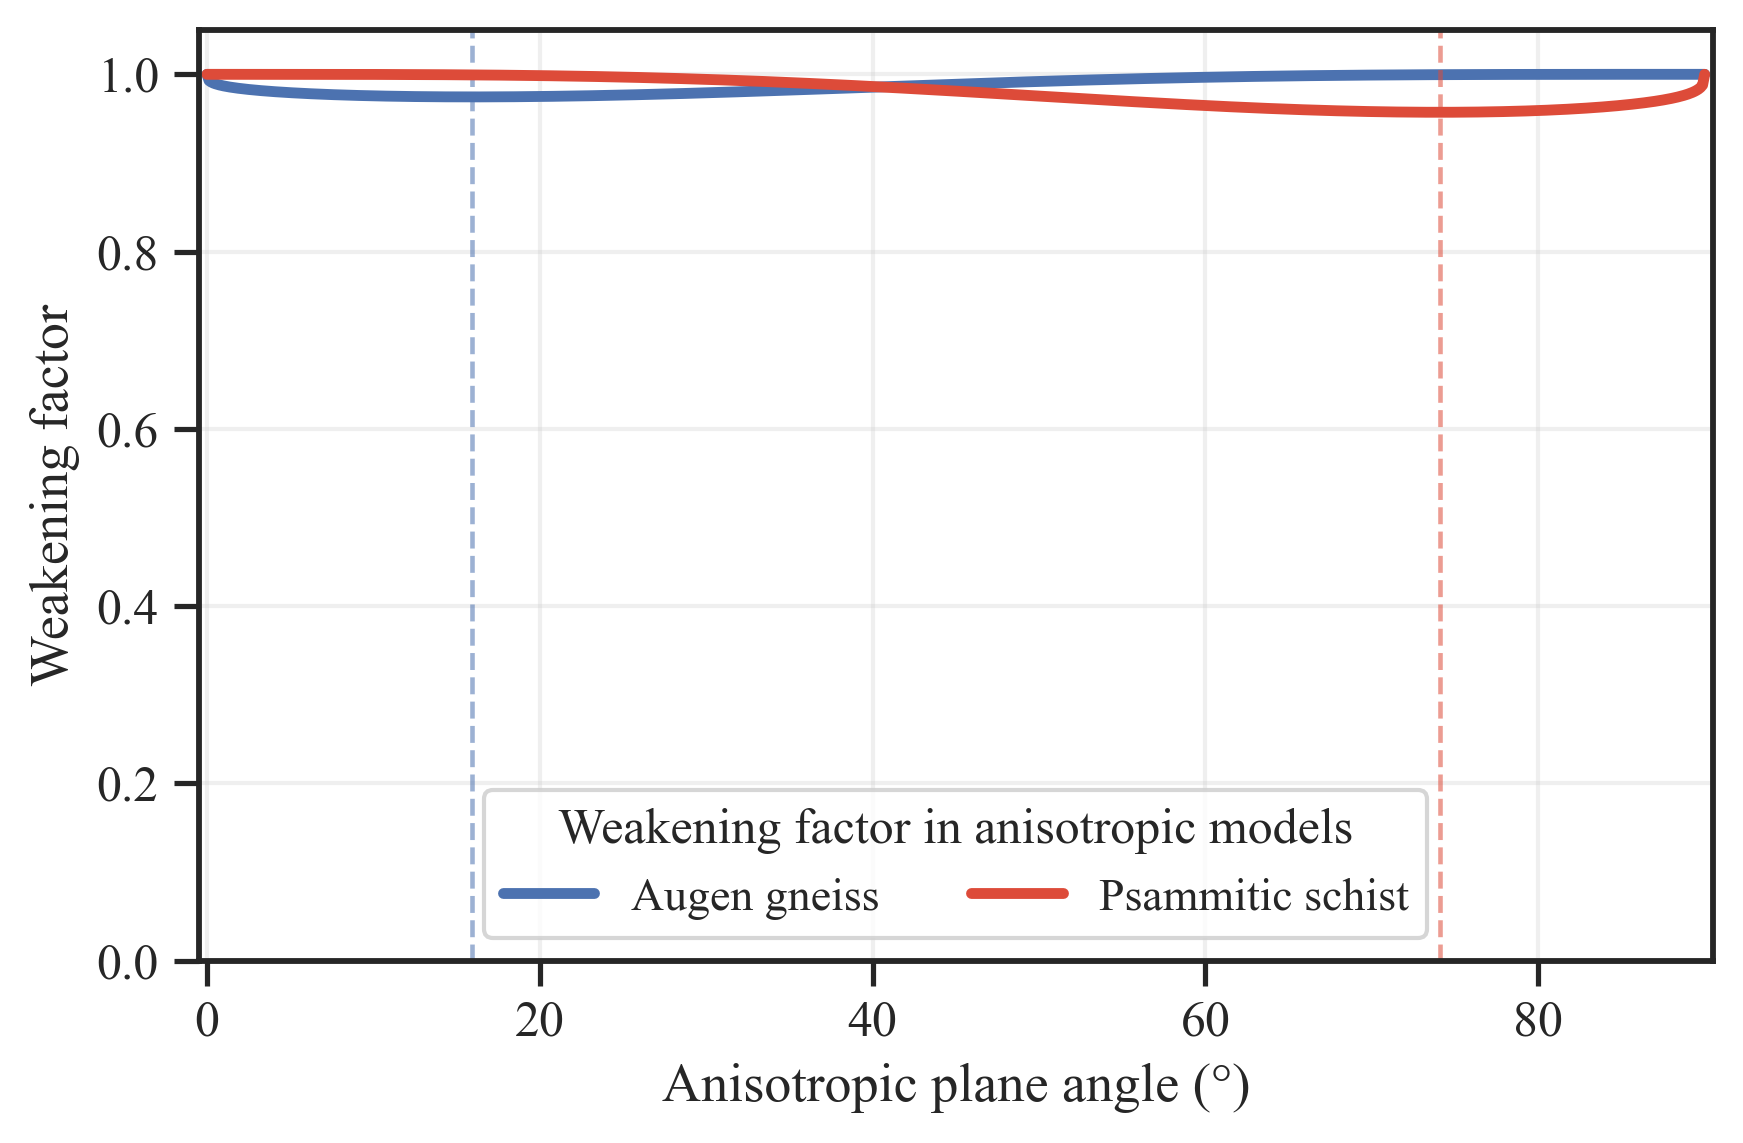

Saved: /Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/Output_Figures/Weakening_factor_both_rocks.pdf


In [6]:
# ------------------------------------------------------------
# 7) Separate figure: M7 weakening factor (both rocks together)
# ------------------------------------------------------------
fig_w, ax_w = plt.subplots(figsize=(6, 4))

ang_f = np.linspace(0, 90, 721)
beta_f = np.deg2rad(ang_f)

weak_handles = []

for rock_name, popt in [
    ("Augen gneiss", aug_popt),
    ("Psammitic schist", psam_popt),
]:
    if popt is None:
        continue

    color = rock_colors[rock_name]

    sigma0, sigma90, eta, u = popt
    xi = xi_from_u(u)
    g = asym_activation(beta_f, xi)
    weakening_factor = 1.0 / np.sqrt(1.0 + eta * g**2)
    beta_star = trough_angle_from_xi(xi)

    ax_w.plot(
        ang_f,
        weakening_factor,
        color=color,
        lw=2.6,
        label=f"{rock_name}"
    )

    ax_w.axvline(
        beta_star,
        color=color,
        lw=1.1,
        ls="--",
        alpha=0.55
    )

ax_w.set_xlim(-0.5, 90.5)
ax_w.set_ylim(0, 1.05)
ax_w.set_xlabel("Anisotropic plane angle (°)")
ax_w.set_ylabel("Weakening factor")
ax_w.grid(True, alpha=0.3)
ax_w.legend(
    loc="best",
    ncol=2,
    frameon=True,
    title="Weakening factor in anisotropic models"
)

plt.tight_layout()

outpath_w = os.path.join(output_dir, "Weakening_factor_both_rocks.pdf")
plt.savefig(outpath_w, dpi=300, bbox_inches="tight", format="pdf")
plt.show()

print(f"Saved: {outpath_w}")

